In [1]:
import pandas as pd
import numpy as np

In [2]:
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

from keybert import KeyBERT
kw_model = KeyBERT()
print("✅ KeyBERT ready")

from bertopic import BERTopic
topic_model = BERTopic(verbose=True)
print("✅ BERTopic ready")

print("Thesis keyword extraction + topic modeling ready!")

/home/20236408/thesis_env/lib/python3.12/site-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


✅ KeyBERT ready
✅ BERTopic ready
Thesis keyword extraction + topic modeling ready!


## BERTopic

Next, there are two main ways to further fine-tune these specific topic representations, namely globally and evolutionary.

A topic representation at timestep t can be fine-tuned **globally** by averaging its c-TF-IDF representation with that of the global representation. This allows each topic representation to move slightly towards the global representation whilst still keeping some of its specific words.

A topic representation at timestep t can be fine-tuned **evolutionary** by averaging its c-TF-IDF representation with that of the c-TF-IDF representation at timestep t-1. This is done for each topic representation allowing for the representations to evolve over time.

Both fine-tuning methods are set to True as a default and allow for interesting representations to be created.

In [3]:
df = pd.read_csv("Data/corpus_df_processed.csv")
df.head()

,ID,Source_File,Newspaper,Date,Length,Section,Author,Edition,Headline,Graphic,Article
0,1,"D:/JADS/Thesis/Data/' American Fiction', gebas...",de Volkskrant,2024-03-07,514 words,"V; Blz. 8, 9",PAULINE KLEIJER,NaN,"'American Fiction', gebaseerd op Percival Ever...",False,Thelonious 'Monk' Ellison schrijft doorwrochte...
1,2,D:/JADS/Thesis/Data/' BBC -presentator over de...,AD/Algemeen Dagblad,2023-07-10,80 words,Landelijk; Blz. 2,NaN,NaN,'BBC-presentator over de schreef',False,De Britse regering eist opheldering van de BBC...
2,3,D:/JADS/Thesis/Data/' Bij mij is het alles of ...,De Telegraaf,2022-09-17,1433 words,VROUW; Blz. NaN,NaN,NaN,'Bij mij is het alles of niets',False,In 2006 werd ze tweede in het eerste seizoen v...
3,4,D:/JADS/Thesis/Data/' Bij mij runnen vrouwende...,AD/Algemeen Dagblad,2025-12-12,796 words,"Media en Cultuur; Blz. 28, 29",MEREL VAN BAAL,NaN,'Bij mij runnen vrouwende boel',False,Acteur en maker Robert de Hoog is terug met hi...
4,5,D:/JADS/Thesis/Data/' Bodem ' is herkenbaar op...,de Volkskrant,2025-11-03,454 words,V; Blz. 10,MARK MOORMAN,NaN,"'Bodem' is herkenbaar op ramkoers, met ontroer...",False,"recensieâ€…\nDe comedy-dramaserie Bodem, gespe..."


In [4]:
from bertopic import BERTopic

topic_model = BERTopic(verbose=True)
topics, probs = topic_model.fit_transform(df["Article"])

2026-04-10 14:40:43,186 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/807 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
mask = df["Date"].notna() & df["Article"].notna()

topics_over_time = topic_model.topics_over_time(
df.loc[mask, "Article"].astype(str).tolist(),
df.loc[mask, "Date"].tolist(), global_tuning=True,
nr_bins=20
)

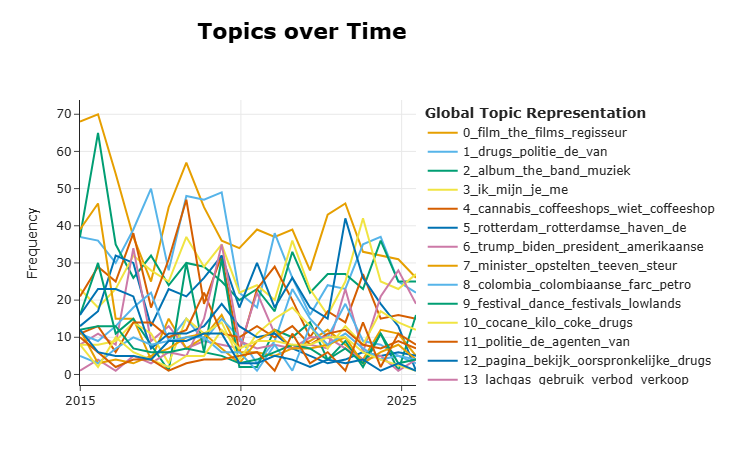

In [6]:
topic_model.visualize_topics_over_time(topics_over_time, top_n_topics=20)

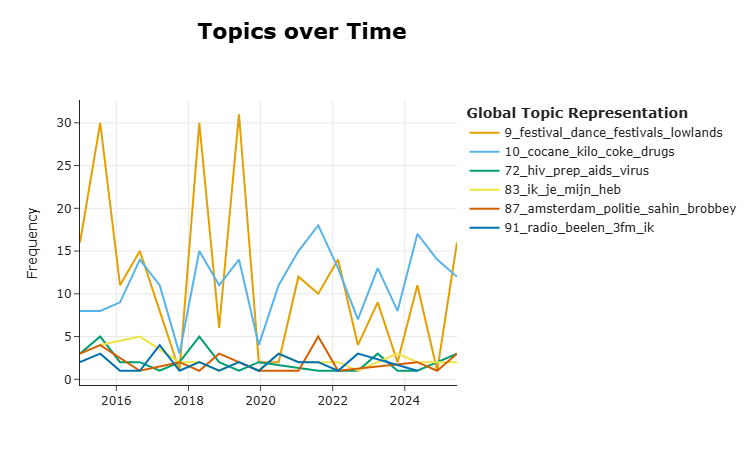

In [7]:
topic_model.visualize_topics_over_time(topics_over_time, topics=[9, 10, 72, 83, 87, 91])

## NewsBERTje

In [8]:
import re
from keybert import KeyBERT
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

In [9]:
# 1) Load NEWSBERTje sentiment model
MODEL_NAME = "LoicDL/NewsBERTje-base"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)

sentiment_pipe = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    return_all_scores=True,
    truncation=True,
    max_length=512
)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at LoicDL/NewsBERTje-base and are newly initialized: ['classifier.weight', 'bert.pooler.dense.weight', 'classifier.bias', 'bert.pooler.dense.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [10]:
# 2) Keyphrase extractor
kw_model = KeyBERT()

def clean_text(text):
    """Pre-processes text like paper: removes extra whitespace, handles NaN"""
    if pd.isna(text):
        return ""
    text = str(text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

  
def split_paragraphs(text):
    """Splits article into paragraphs (paper finds paragraphs containing aspects)"""
    text = str(text)
    paragraphs = [p.strip() for p in re.split(r"\n\s*\n", text) if p.strip()]

    if len(paragraphs) <= 1:
        sentences = re.split(r'(?<=[.!?])\s+', text)
        chunk_size = 4
        paragraphs = [
            " ".join(sentences[i:i+chunk_size]).strip()
            for i in range(0, len(sentences), chunk_size)
            if " ".join(sentences[i:i+chunk_size]).strip()
        ]
    return paragraphs


def extract_aspects(text, top_n=10):
    text = clean_text(text)
    if not text:
        return []
    
    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 3), # Bouzoubaa et al. used 1-3 grams
        stop_words=None,
        use_mmr=True,
        diversity=0.5,
        top_n=top_n
    )
    
    return [{"aspect": kw, "relevance": float(score)} for kw, score in keywords]


def find_relevant_paragraphs(text, aspect):
    paragraphs = split_paragraphs(text)
    aspect_lower = aspect.lower()
    return [para for para in paragraphs if aspect_lower in para.lower()]

def ensure_score_list(pipe_output):
    """
    Standardize HF pipeline output to a list of dicts:
    [{'label': ..., 'score': ...}, ...]
    """
    if isinstance(pipe_output, dict):
        return [pipe_output]

    if isinstance(pipe_output, list):
        if len(pipe_output) == 0:
            return []
        if isinstance(pipe_output[0], dict):
            return pipe_output
        if isinstance(pipe_output[0], list):
            return pipe_output[0]

    raise ValueError(f"Unexpected pipeline output format: {type(pipe_output)} | {pipe_output}")

def normalize_label_scores(score_dict, model):
    """
    Convert one HF output dict into:
    {'positive': x, 'neutral': y, 'negative': z}
    """
    out = {"positive": 0.0, "neutral": 0.0, "negative": 0.0}
    id2label = getattr(model.config, "id2label", {})

    raw_label = score_dict.get("label")
    score = float(score_dict.get("score", 0.0))

    label = raw_label
    if isinstance(raw_label, str) and raw_label.startswith("LABEL_"):
        try:
            idx = int(raw_label.replace("LABEL_", ""))
            label = id2label.get(idx, raw_label)
        except:
            label = raw_label

    label_lower = str(label).lower()

    if "pos" in label_lower:
        out["positive"] = score
    elif "neg" in label_lower:
        out["negative"] = score
    elif "neu" in label_lower:
        out["neutral"] = score

    return out


def sentiment_score_from_probs(probs):
    """
    Paper's normalized sentiment score:
    SS = (positive - negative) / (positive + negative)
    Range: [-1, 1]
    """
    pos = probs["positive"]
    neg = probs["negative"]
    denom = pos + neg
    
    if denom == 0:
        return 0.0
    
    return (pos - neg) / denom


def score_paragraph(paragraph, sentiment_pipe, model):
    """
    Scores one paragraph with NEWSBERTje.
    Scoring each aspect-containing paragraph, then computes SS.
    """
    raw_output = sentiment_pipe(paragraph, truncation=True, max_length=512)
    if isinstance(raw_output[0], list):
        score_dict = raw_output[0][0]  # Take first dict from list
    else:
        score_dict = raw_output[0]
    probs = normalize_label_scores(score_dict, model)
    ss = sentiment_score_from_probs(probs)

    return {
        "positive_prob": probs["positive"],
        "neutral_prob": probs["neutral"],
        "negative_prob": probs["negative"],
        "sentiment_score": ss
    }


def score_aspect_in_article(article_text, aspect, sentiment_pipe, model):
    """Full aspect pipeline: find paragraphs → score each → return all scores"""
    relevant_paragraphs = find_relevant_paragraphs(article_text, aspect)
    
    if not relevant_paragraphs:
        return []
    
    rows = []
    for para in relevant_paragraphs:
        scored = score_paragraph(para, sentiment_pipe, model)
        rows.append({
            "aspect": aspect,
            "paragraph": para,
            "positive_prob": scored["positive_prob"],
            "neutral_prob": scored["neutral_prob"],
            "negative_prob": scored["negative_prob"],
            "sentiment_score": scored["sentiment_score"]
        })
    
    return rows


# def analyze_single_article(article_text, sentiment_pipe, model, top_n_aspects=10, min_relevance=0.0):
#     """Processes ONE article: extract aspects → score relevant paragraphs (paper's per-article step)"""
#     article_text = clean_text(article_text)
#     if not article_text:
#         return pd.DataFrame()
    
#     aspects = extract_aspects(article_text, top_n=top_n_aspects)
#     aspects = [a for a in aspects if a["relevance"] >= min_relevance]
    
#     all_rows = []
#     for a in aspects:
#         aspect_rows = score_aspect_in_article(
#             article_text=article_text,
#             aspect=a["aspect"],
#             sentiment_pipe=sentiment_pipe,
#             model=model
#         )
#         for row in aspect_rows:
#             row["aspect_relevance"] = a["relevance"]
#             all_rows.append(row)
    
#     return pd.DataFrame(all_rows)


def analyze_df(
    df,
    sentiment_pipe,
    model,
    article_col="Article",
    id_col=None,
    year_col=None,
    group_col=None,
    top_n_aspects=10,
    min_relevance=0.0,
    max_articles=None
):
    """
    Long-format output:
    one row per article x aspect x relevant paragraph
    """
    results = []
    
    working_df = df.copy()
    if max_articles is not None:
        working_df = working_df.head(max_articles)
    
    for idx, row in working_df.iterrows():
        article_text = row.get(article_col, "")
        article_text = clean_text(article_text)
        
        if not article_text:
            continue
        
        aspects = extract_aspects(article_text, top_n=top_n_aspects)
        aspects = [a for a in aspects if a["relevance"] >= min_relevance]
        
        for a in aspects:
            aspect_rows = score_aspect_in_article(
                article_text=article_text,
                aspect=a["aspect"],
                sentiment_pipe=sentiment_pipe,
                model=model
            )
            
            for r in aspect_rows:
                out = {
                    "row_index": idx,
                    "article_id": row[id_col] if id_col and id_col in row else idx,
                    "aspect": r["aspect"],
                    "aspect_relevance": a["relevance"],
                    "paragraph": r["paragraph"],
                    "positive_prob": r["positive_prob"],
                    "neutral_prob": r["neutral_prob"],
                    "negative_prob": r["negative_prob"],
                    "sentiment_score": r["sentiment_score"]
                }
                
                if year_col and year_col in row:
                    out["year"] = row[year_col]
                
                if group_col and group_col in row:
                    out["group"] = row[group_col]
                
                results.append(out)
    
    return pd.DataFrame(results)

In [11]:
def summarize_aspect_sentiment(results_df):
    """Aggregates like paper: mean SS per aspect/year/group"""
    if results_df.empty:
        return pd.DataFrame()
    
    group_fields = ["aspect"]
    if "year" in results_df.columns:
        group_fields = ["year", "aspect"]
    if "group" in results_df.columns and "year" in results_df.columns:
        group_fields = ["group", "year", "aspect"]
    elif "group" in results_df.columns:
        group_fields = ["group", "aspect"]
    
    summary = (
        results_df
        .groupby(group_fields, as_index=False)
        .agg(
            mean_sentiment_score=("sentiment_score", "mean"),
            mean_positive_prob=("positive_prob", "mean"),
            mean_negative_prob=("negative_prob", "mean"),
            mean_neutral_prob=("neutral_prob", "mean"),
            n_paragraphs=("paragraph", "count"),
            n_articles=("article_id", "nunique")
        )
        .sort_values("n_articles", ascending=False)
    )
    
    return summary


def summarize_article_sentiment(results_df):
    """Overall article-level sentiment (paper's global stats)"""
    if results_df.empty:
        return pd.DataFrame()
    
    group_fields = ["article_id"]
    if "year" in results_df.columns:
        group_fields.append("year")
    if "group" in results_df.columns:
        group_fields.append("group")
    
    summary = (
        results_df
        .groupby(group_fields, as_index=False)
        .agg(
            article_mean_sentiment=("sentiment_score", "mean"),
            n_aspects=("aspect", "nunique"),
            n_paragraphs=("paragraph", "count")
        )
    )
    
    return summary

In [ ]:
results_df = analyze_df(
    df=df,  # your dataframe with 'Article' column
    sentiment_pipe=sentiment_pipe,
    model=model,
    article_col="Article",
    top_n_aspects=8,
    min_relevance=0.0
)

aspect_summary = summarize_aspect_sentiment(results_df)
print(aspect_summary.head(10))